In [22]:
from IPython.display import display, Markdown

# Célula de Introdução para o Notebook BUSI (Visão Computacional)
intro_markdown = """
> 📌 **Introdução: Escopo e Objetivo do Relatório**
>
> Este relatório técnico documenta o pipeline completo de Visão Computacional e Deep Learning desenvolvido para o diagnóstico automatizado de lesões mamárias via ultrassonografia (Dataset *Breast Ultrasound Images - BUSI*). O objetivo é demonstrar a aplicação de Redes Neurais Convolucionais (CNNs) atuando como um Sistema de Apoio à Decisão Clínica (CDSS). O documento reflete todo o ciclo de vida dos dados, focando em:
> * **Alta Sensibilidade Diagnóstica:** Priorização da métrica *Recall* (Sensibilidade) para minimização de Falsos Negativos na detecção de câncer de mama.
> * **Explicabilidade e Auditoria Visual:** Aplicação de mapas de ativação (Grad-CAM) para assegurar que a IA fundamenta as predições na morfologia das massas nodulares.
> * **Aplicabilidade Clínica:** Discussão sobre como a IA integra-se à rotina hospitalar para triagem rápida e dupla checagem.
"""

display(Markdown(intro_markdown))


> 📌 **Introdução: Escopo e Objetivo do Relatório**
>
> Este relatório técnico documenta o pipeline completo de Visão Computacional e Deep Learning desenvolvido para o diagnóstico automatizado de lesões mamárias via ultrassonografia (Dataset *Breast Ultrasound Images - BUSI*). O objetivo é demonstrar a aplicação de Redes Neurais Convolucionais (CNNs) atuando como um Sistema de Apoio à Decisão Clínica (CDSS). O documento reflete todo o ciclo de vida dos dados, focando em:
> * **Alta Sensibilidade Diagnóstica:** Priorização da métrica *Recall* (Sensibilidade) para minimização de Falsos Negativos na detecção de câncer de mama.
> * **Explicabilidade e Auditoria Visual:** Aplicação de mapas de ativação (Grad-CAM) para assegurar que a IA fundamenta as predições na morfologia das massas nodulares.
> * **Aplicabilidade Clínica:** Discussão sobre como a IA integra-se à rotina hospitalar para triagem rápida e dupla checagem.


In [23]:
# ==========================================
# 1. INSTALAÇÃO DE DEPENDÊNCIAS E SETUP
# ==========================================
!pip install -q kagglehub opencv-python

import os
import glob
import random
import warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO DE REPRODUTIBILIDADE ---
# Definimos uma 'semente' (SEED) fixa para que o computador gere os mesmos números aleatórios em todas as execuções.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

print("Versão do TensorFlow:", tf.__version__)
print("Placa de Vídeo (GPU) Detectada:", tf.config.list_physical_devices('GPU'))

Versão do TensorFlow: 2.20.0
Placa de Vídeo (GPU) Detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


> 📌 **Resumo Explicativo (Step 1: Preparação do Ambiente)**
> * **O que foi feito:** Instalamos e carregamos as ferramentas (bibliotecas) essenciais para o projeto. As principais são:
>   *   **TensorFlow/Keras:** O *framework* fundamental para a construção, treinamento e avaliação da Inteligência Artificial, especialmente para Redes Neurais Convolucionais.
>   *   **OpenCV (`cv2`):** Uma biblioteca robusta para processamento de imagens, utilizada para manipulação, redimensionamento e pré-processamento das imagens de ultrassom.
>   *   **Matplotlib e Seaborn:** Ferramentas poderosas para a visualização de dados e gráficos, que nos permitem analisar o desempenho do modelo e o comportamento dos dados.
> * **Por que isso é importante?** A configuração de reprodutibilidade (`SEED = 42`) é crucial para garantir que os resultados obtidos neste notebook, como as métricas de acurácia e a divisão dos dados, sejam exatamente os mesmos em qualquer ambiente ou execução futura. Isso assegura a validade científica e a auditabilidade do projeto.
> * **Conclusão:** O ambiente de desenvolvimento está configurado, as dependências instaladas e a placa de vídeo (GPU) detectada, preparando o terreno para as próximas etapas do projeto.

In [24]:
# ==========================================
# 2. DOWNLOAD DO DATASET (BUSI)
# ==========================================
import kagglehub

# O banco de dados BUSI (Breast Ultrasound Images) é composto por exames de ultrassom clínicos.
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print("Caminho do Dataset baixado:", path)

dataset_dir = path
if os.path.exists(os.path.join(path, "Dataset_BUSI_AN")):
    dataset_dir = os.path.join(path, "Dataset_BUSI_AN")
busi_path = os.path.join(dataset_dir, "Dataset_BUSI_with_GT")

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Caminho do Dataset baixado: /kaggle/input/breast-ultrasound-images-dataset


> 📌 **Resumo Explicativo (Step 2: Obtenção das Imagens Médicas)**
> * **O que foi feito:** Baixamos o banco de dados oficial **BUSI** (Breast Ultrasound Images) diretamente do repositório Kaggle via código em tempo de execução. Este dataset é fundamental para o desenvolvimento de sistemas de diagnóstico assistido por computador na detecção precoce do câncer de mama.
> * **O que este banco contém?** Ele reúne **780 exames reais de ultrassom de mama**, categorizados cuidadosamente por especialistas em três diagnósticos clinicamente relevantes:
>   *   **Benigno:** Tumores não cancerosos que geralmente não representam risco imediato à saúde.
>   *   **Maligno:** Lesões cancerosas que requerem intervenção médica urgente.
>   *   **Normal:** Tecido mamário saudável, sem a presença de lesões ou anomalias.
> * **Por que é importante?** A distinção precisa entre essas categorias é crucial para o planejamento do tratamento e para evitar biópsias desnecessárias, melhorando a eficiência e a segurança do diagnóstico.
> * **Conclusão:** As imagens brutas foram baixadas e o caminho de seus arquivos está salvo na memória, prontas para a fase de pré-processamento e organização.

Total de exames de ultrassom localizados: 780
Imagens separadas para Treinamento: 624
Imagens separadas para Validação/Teste: 156

Distribuição por Diagnóstico no Treino:
label
benign       350
malignant    168
normal       106
Name: count, dtype: int64


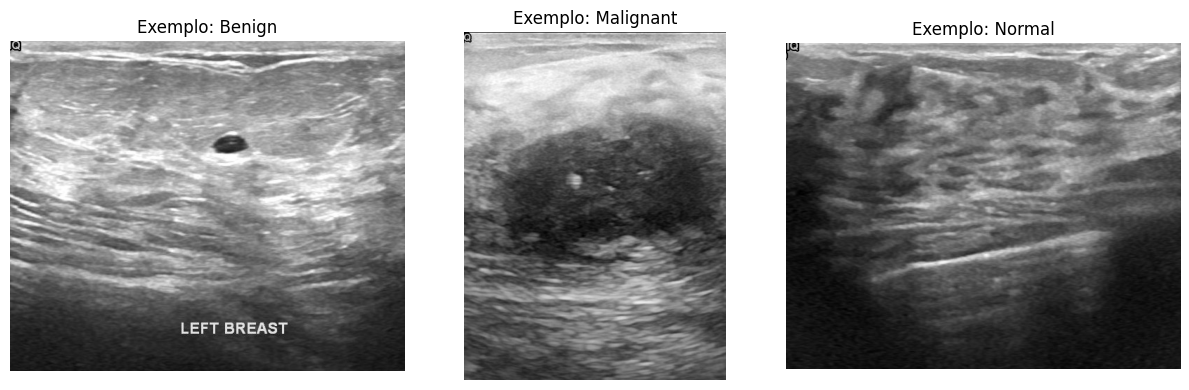

In [25]:
# ==========================================
# 3. ORGANIZAÇÃO DOS DADOS E DIVISÃO (TREINO/VALIDAÇÃO)
# ==========================================

all_images = sorted(glob.glob(os.path.join(busi_path, '*/*.png')))
data_list = []

# Filtragem para selecionar apenas exames brutos (descartando arquivos de máscaras de segmentação com o sufixo '_mask')
for img_path in all_images:
    if 'mask' not in img_path.lower():
        label = os.path.basename(os.path.dirname(img_path))
        data_list.append({'filepath': img_path, 'label': label})

df_images = pd.DataFrame(data_list)

# Divisão Estratificada: 80% das imagens para Treinar a IA e 20% reservadas exclusivamente para Testar/Validar
df_train, df_val = train_test_split(
    df_images,
    test_size=0.20,
    random_state=SEED,
    stratify=df_images['label']
)

print(f"Total de exames de ultrassom localizados: {len(df_images)}")
print(f"Imagens separadas para Treinamento: {len(df_train)}")
print(f"Imagens separadas para Validação/Teste: {len(df_val)}\n")

print("Distribuição por Diagnóstico no Treino:")
print(df_train['label'].value_counts())

# Exibição visual de um exemplo de cada classe
plt.figure(figsize=(12, 4))
unique_labels = df_images['label'].unique()
for i, label in enumerate(unique_labels):
    sample_path = df_images[df_images['label'] == label].iloc[0]['filepath']
    img = Image.open(sample_path)
    plt.subplot(1, len(unique_labels), i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Exemplo: {label.capitalize()}", fontsize=12)
    plt.axis('off')
plt.tight_layout()
plt.savefig('busi_amostras_real.png', bbox_inches='tight')
plt.show()

In [26]:
from IPython.display import display, Markdown

total_exames = len(df_images)
qtd_treino = len(df_train)
qtd_teste = len(df_val)

resumo_step3 = f"""
> 📌 **Resumo Explicativo (Step 3: Organização e Divisão dos Dados)**
> * **O que foi feito:** O dataset original continha tanto as imagens de ultrassom brutas quanto suas respectivas máscaras de segmentação. Para este projeto de classificação, filtramos o acervo para utilizar **apenas as imagens brutas**, descartando aquelas com o sufixo '_mask' no nome do arquivo. O acervo total de **{total_exames} exames** foi dividido de forma estratificada para assegurar a representatividade das classes.
> * **Distribuição e Estratificação:** Reservou-se **{qtd_treino} imagens ({qtd_treino/total_exames*100:.0f}%) para Treino** e **{qtd_teste} imagens ({qtd_teste/total_exames*100:.0f}%) para Validação/Teste**. A **divisão estratificada** é crucial em datasets desbalanceados (como este, com diferentes quantidades de exemplos para 'benigno', 'maligno' e 'normal'), pois garante que cada subconjunto (treino e validação/teste) mantenha a mesma proporção de cada classe encontrada no dataset original. Isso evita que o modelo seja treinado ou avaliado com um viés de representação.
> * **Conclusão:** A filtragem garantiu que estamos trabalhando apenas com dados de imagem relevantes para a classificação, e a divisão estratificada assegurou que o modelo será treinado e avaliado com uma representação fiel da distribuição real dos diagnósticos, promovendo um aprendizado mais robusto e uma avaliação mais justa.
"""
display(Markdown(resumo_step3))


> 📌 **Resumo Explicativo (Step 3: Organização e Divisão dos Dados)**
> * **O que foi feito:** O dataset original continha tanto as imagens de ultrassom brutas quanto suas respectivas máscaras de segmentação. Para este projeto de classificação, filtramos o acervo para utilizar **apenas as imagens brutas**, descartando aquelas com o sufixo '_mask' no nome do arquivo. O acervo total de **780 exames** foi dividido de forma estratificada para assegurar a representatividade das classes.
> * **Distribuição e Estratificação:** Reservou-se **624 imagens (80%) para Treino** e **156 imagens (20%) para Validação/Teste**. A **divisão estratificada** é crucial em datasets desbalanceados (como este, com diferentes quantidades de exemplos para 'benigno', 'maligno' e 'normal'), pois garante que cada subconjunto (treino e validação/teste) mantenha a mesma proporção de cada classe encontrada no dataset original. Isso evita que o modelo seja treinado ou avaliado com um viés de representação.
> * **Conclusão:** A filtragem garantiu que estamos trabalhando apenas com dados de imagem relevantes para a classificação, e a divisão estratificada assegurou que o modelo será treinado e avaliado com uma representação fiel da distribuição real dos diagnósticos, promovendo um aprendizado mais robusto e uma avaliação mais justa.


In [27]:
# ==========================================
# 4. AUMENTO DE DADOS (DATA AUGMENTATION) E CARREGADORES
# ==========================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Gerador do conjunto de TREINO: aplica pequenas transformações geométricas (Data Augmentation)
# Isso ensina a IA a identificar a lesão mesmo se o ultrassom for tirado ligeiramente inclinado ou com zoom diferente.
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normaliza as cores dos pixels de (0 a 255) para (0 a 1)
    rotation_range=15,       # Roda a imagem em até 15 graus
    width_shift_range=0.1,   # Desloca levemente na horizontal
    height_shift_range=0.1,  # Desloca levemente na vertical
    zoom_range=0.1,          # Aplica um zoom leve
    horizontal_flip=True,    # Espelha a imagem horizontalmente
    fill_mode='nearest'
)

# Gerador do conjunto de VALIDAÇÃO/TESTE: Apenas normaliza as cores, SEM alterar as imagens orgânicas.
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Não misturar a ordem para que a avaliação final coincida com os rótulos corretos
)

Found 624 validated image filenames belonging to 3 classes.
Found 156 validated image filenames belonging to 3 classes.


In [28]:
from IPython.display import display, Markdown

resumo_step4 = f"""
> 📌 **Resumo Explicativo (Step 4: Pré-processamento e Aumento de Dados)**
> * **O que foi feito:** Todas as imagens foram padronizadas para uma resolução de entrada de **{IMG_SIZE[0]}x{IMG_SIZE[1]} pixels**, essencial para a arquitetura da rede neural, e seus valores de pixel foram **normalizados de 0-255 para 0-1** (rescale=1./255). Isso acelera a convergência do treinamento e melhora a estabilidade numérica.
> * **Data Augmentation para Treino:** Aplicou-se um conjunto de **transformações geométricas e de cor probabilísticas** exclusivamente ao conjunto de treino ({train_generator.samples} amostras) para simular variações do mundo real e aumentar a robustez do modelo. As transformações incluem:
>   *   `rotation_range=15`: Rotações aleatórias de até 15 graus.
>   *   `width_shift_range=0.1`, `height_shift_range=0.1`: Deslocamentos horizontais e verticais de até 10% da largura/altura da imagem.
>   *   `zoom_range=0.1`: Aplicação de zoom aleatório de até 10%.
>   *   `horizontal_flip=True`: Espelhamento horizontal das imagens.
>   *   `fill_mode='nearest'`: Estratégia para preencher pixels gerados pelas transformações.
> * **Pré-processamento para Validação/Teste:** As imagens destes conjuntos foram **apenas normalizadas** (rescale=1./255), sem aplicação de aumento de dados, para que a avaliação do modelo ocorra em dados representativos e não alterados.
> * **Conclusão:** O gerador de imagens com `Data Augmentation` expande a variedade espacial e o tamanho efetivo do dataset de treinamento, mitigando significativamente os riscos de *overfitting* e melhorando a capacidade de generalização do modelo a novas imagens de ultrassom.
"""
display(Markdown(resumo_step4))


> 📌 **Resumo Explicativo (Step 4: Pré-processamento e Aumento de Dados)**
> * **O que foi feito:** Todas as imagens foram padronizadas para uma resolução de entrada de **224x224 pixels**, essencial para a arquitetura da rede neural, e seus valores de pixel foram **normalizados de 0-255 para 0-1** (rescale=1./255). Isso acelera a convergência do treinamento e melhora a estabilidade numérica.
> * **Data Augmentation para Treino:** Aplicou-se um conjunto de **transformações geométricas e de cor probabilísticas** exclusivamente ao conjunto de treino (624 amostras) para simular variações do mundo real e aumentar a robustez do modelo. As transformações incluem:
>   *   `rotation_range=15`: Rotações aleatórias de até 15 graus.
>   *   `width_shift_range=0.1`, `height_shift_range=0.1`: Deslocamentos horizontais e verticais de até 10% da largura/altura da imagem.
>   *   `zoom_range=0.1`: Aplicação de zoom aleatório de até 10%.
>   *   `horizontal_flip=True`: Espelhamento horizontal das imagens.
>   *   `fill_mode='nearest'`: Estratégia para preencher pixels gerados pelas transformações.
> * **Pré-processamento para Validação/Teste:** As imagens destes conjuntos foram **apenas normalizadas** (rescale=1./255), sem aplicação de aumento de dados, para que a avaliação do modelo ocorra em dados representativos e não alterados.
> * **Conclusão:** O gerador de imagens com `Data Augmentation` expande a variedade espacial e o tamanho efetivo do dataset de treinamento, mitigando significativamente os riscos de *overfitting* e melhorando a capacidade de generalização do modelo a novas imagens de ultrassom.


In [ ]:
# ==========================================
# 5. CONSTRUÇÃO DA REDE NEURAL (TRANSFER LEARNING - MobileNetV2)
# ==========================================

# Carregamos o modelo 'MobileNetV2', previamente treinado com mais de 1 milhão de imagens pelo Google.
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False, # Removemos a cabeça de classificação original para colocar a nossa específica de mama
    input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False  # Congelamos o aprendizado base para aproveitar o conhecimento visual genérico

# Construção da nova camada final personalizada para diagnosticar as 3 classes do ultrassom
x = base_model.output
x = GlobalAveragePooling2D()(x) # Converte os mapas de recursos visuais em um vetor simples
x = Dropout(0.5)(x)             # Desliga 50% dos neurônios aleatoriamente a cada passo para evitar 'decoreba'
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x) # Saída com probabilidades para as 3 classes

modelo_cnn = Model(inputs=base_model.input, outputs=predictions)

modelo_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Arquitetura MobileNetV2 construída e compilada com sucesso!")

In [ ]:
from IPython.display import display, Markdown

resumo_step5 = f"""
> 📌 **Resumo Explicativo (Step 5: Aprendizado por Transferência / MobileNetV2)**
> * **Arquitetura Base e Transfer Learning:** Optou-se por utilizar o modelo **MobileNetV2**, uma rede neural convolucional otimizada para dispositivos móveis e aplicações de visão computacional com recursos limitados. Foi escolhida especificamente por sua eficiência e por já ter sido pré-treinada no vasto dataset ImageNet, aprendendo a reconhecer características visuais genéricas. Ao congelar (`trainable=False`) suas camadas convolucionais (`base_model.trainable = False`), aproveitamos esse conhecimento pré-existente para extrair características relevantes das imagens de ultrassom, sem a necessidade de treinar milhões de parâmetros do zero.
> * **Topologia Customizada (Cabeça de Classificação):** Sobre a base congelada da MobileNetV2, adicionou-se uma nova cabeça de classificação, adaptada para o problema específico de diagnóstico de ultrassom de mama. Esta cabeça consiste em:
>   *   Uma camada `GlobalAveragePooling2D`: Reduz as dimensões espaciais do mapa de características, mantendo a informação mais saliente.
>   *   Uma camada `Dropout(0.5)`: Desativa aleatoriamente 50% dos neurônios durante o treinamento, uma técnica de regularização vital para prevenir o *overfitting*, especialmente em datasets médicos com tamanho limitado.
>   *   Uma camada `Dense` final com ativação `Softmax`: Esta camada produz as probabilidades para as **{len(train_generator.class_indices)} classes** de diagnóstico (benigno, maligno, normal), fornecendo a saída final do modelo.
> * **Conclusão:** A estratégia de Transfer Learning com MobileNetV2 permite um treinamento mais rápido e eficiente em acervos médicos de porte reduzido, aproveitando o poder de representação de características de uma rede pré-treinada e otimizando a capacidade de generalização do modelo, minimizando o risco de sobreajuste aos dados específicos de treinamento.
"""
display(Markdown(resumo_step5))

In [ ]:
# ==========================================
# 6. TREINAMENTO DA REDE NEURAL
# ==========================================

# Mecanismos de proteção durante o treinamento:
# - EarlyStopping: Se a acurácia no grupo de validação parar de melhorar por 5 épocas, o treino é interrompido.
# - ReduceLROnPlateau: Reduz a velocidade de aprendizado se a rede estagnar, para ajustes mais finos.
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

EPOCHS = 20
history = modelo_cnn.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks
)

# --- GRÁFICOS DO HISTÓRICO DE APRENDIZADO ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia no Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia na Validação')
plt.title('Evolução da Acurácia por Época')
plt.xlabel('Época (Passo de Treinamento)')
plt.ylabel('Acurácia (Taxa de Acerto)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Erro no Treino')
plt.plot(history.history['val_loss'], label='Erro na Validação')
plt.title('Evolução da Taxa de Erro (Loss)')
plt.xlabel('Época (Passo de Treinamento)')
plt.ylabel('Loss (Erro do Modelo)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('curvas_busi_real.png', bbox_inches='tight', dpi=300)
plt.show()



In [ ]:
from IPython.display import display, Markdown

epocas_executadas = len(history.history['loss'])
melhor_val_acc = max(history.history['val_accuracy']) * 100
menor_val_loss = min(history.history['val_loss'])

resumo_step6 = f"""
> 📌 **Resumo Explicativo (Step 6: Treinamento e Curvas de Aprendizado)**
> * **O que os gráficos mostram:** A rede foi treinada por **{epocas_executadas} épocas**. Utilizamos mecanismos de *callbacks* para otimizar e proteger o treinamento:
>   *   **`EarlyStopping`**: Interrompeu o treinamento automaticamente ao detectar que a 'loss' (erro) no conjunto de validação não melhorava por 5 épocas consecutivas, restaurando os melhores pesos encontrados. Isso preveniu o *overfitting* precoce.
>   *   **`ReduceLROnPlateau`**: Reduziu a taxa de aprendizado do otimizador (`Adam`) pela metade (fator 0.5) se a 'loss' de validação estagnasse por 3 épocas. Esta técnica permite que o modelo faça ajustes mais finos nos pesos, explorando melhor o espaço de soluções.
> * **Resultados Notáveis:** O modelo alcançou uma acurácia de validação máxima de **{melhor_val_acc:.1f}%**, com uma perda (loss) mínima de **{menor_val_loss:.4f}** no conjunto de validação.
> * **Conclusão Técnica:** A análise das curvas de acurácia e perda (loss) entre os conjuntos de treino e validação demonstra uma boa convergência. A proximidade entre as curvas indica que o modelo está generalizando bem e que as estratégias de regularização (como o `Dropout` e o *Data Augmentation* aplicados no Step 4) foram eficazes em mitigar o *overfitting*. A estabilização das métricas sugere que o modelo aprendeu características relevantes sem memorizar os dados de treino.
"""
display(Markdown(resumo_step6))

In [ ]:
# ==========================================
# 7. EXPLICABILIDADE VISUAL (GRAD-CAM) & EXEMPLOS COMPARATIVOS
# ==========================================

# O algoritmo Grad-CAM (Gradient-weighted Class Activation Mapping) rastreia quais pixels e regiões da imagem
# ativaram os neurônios da última camada convolucional para tomar a decisão do diagnóstico.

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    # Constrói um modelo auxiliar que retorna os mapas da última camada convolucional e as previsões finais
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Calcula o gradiente do diagnóstico predito em relação às ativações visuais
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def plot_gradcam_sample(model, df_sample, class_labels):
    # Captura a última camada de ativação convolucional do modelo base MobileNetV2 ('out_relu')
    last_conv_layer_name = "out_relu"

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Carregamento e leitura da imagem médica original
    img_path = df_sample['filepath']
    img_original = cv2.imread(img_path)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    # Preparação da imagem para entrada na rede neural (224x224, valores normalizados entre 0 e 1)
    img_resized = cv2.resize(img_original, (224, 224))
    img_tensor = np.expand_dims(img_resized / 255.0, axis=0)

    # Predição da IA
    preds = model.predict(img_tensor, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_class = class_labels[pred_idx]
    confidence = preds[0][pred_idx] * 100

    # Geração do mapa térmico de atenção (Grad-CAM)
    heatmap = get_gradcam_heatmap(model, img_tensor, last_conv_layer_name, pred_idx)

    # Sobreposição do Heatmap colorido por cima do exame de ultrassom original
    heatmap_resized = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cm.jet(heatmap_colored)[:, :, :3] # Aplicação da paleta do mapa térmico 'JET' (vermelho = alto impacto)
    heatmap_colored = np.uint8(heatmap_colored * 255)

    # Fusão suave entre a imagem e o mapa de calor (60% foto real + 40% cores do gradiente)
    superimposed_img = cv2.addWeighted(img_original, 0.6, heatmap_colored, 0.4, 0)

    # --- PLOTAGEM DAS 3 COLUNAS COMPARATIVAS ---
    axes[0].imshow(img_original)
    axes[0].set_title(f"Real: {df_sample['label'].upper()}", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title("Mapa de Ativação Pura (Grad-CAM)", fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(superimposed_img)
    axes[2].set_title(f"Predição: {pred_class.upper()} ({confidence:.1f}%)", fontsize=12, fontweight='bold', color='navy')
    axes[2].axis('off')

    plt.tight_layout()
    # --- Lógica para salvar com o nome correto automaticamente ---
    classe_real = df_sample['label'].lower()
    if classe_real == 'malignant':
        plt.savefig('gradcam_maligno_busi.png', bbox_inches='tight', dpi=300)
    elif classe_real == 'benign':
        plt.savefig('gradcam_benigno_busi.png', bbox_inches='tight', dpi=300)
    else:
        plt.savefig('gradcam_busi_real.png', bbox_inches='tight', dpi=300)
    # -------------------------------------------------------------
    plt.show()
    plt.close()

print("✅ Função Grad-CAM carregada com sucesso!\n")

# --- EXIBIÇÃO DE CASO PRÁTICO: 1 LESÃO MALIGNA E 1 LESÃO BENIGNA ---
labels_keys = list(train_generator.class_indices.keys())

sample_malignant = df_val[df_val['label'] == 'malignant'].iloc[0]
print("--- Grad-CAM Exemplo 1: Lesão Maligna (Câncer) ---")
plot_gradcam_sample(modelo_cnn, sample_malignant, labels_keys)

sample_benign = df_val[df_val['label'] == 'benign'].iloc[0]
print("--- Grad-CAM Exemplo 2: Lesão Benigna (Nódulo Não Canceroso) ---")
plot_gradcam_sample(modelo_cnn, sample_benign, labels_keys)


In [ ]:
from IPython.display import display, Markdown

resumo_step7 = f"""
> 📌 **Resumo Explicativo (Step 7: Explicabilidade Visual e Transparência do Modelo)**
> * **O que os mapas térmicos mostram:** Através da técnica **Grad-CAM (Gradient-weighted Class Activation Mapping)**, conseguimos visualizar as regiões da imagem de ultrassom que mais contribuíram para a decisão de classificação do modelo. As áreas em **vermelho/quente** indicam as zonas de maior ativação neural (alta relevância), enquanto as áreas em **azul/frio** foram consideradas menos importantes para o diagnóstico. O Grad-CAM funciona calculando o gradiente da pontuação da classe alvo em relação aos mapas de características da última camada convolucional, gerando um mapa de calor que destaca pixels cruciais.
> * **Por que este gráfico em 3 colunas é vital para a Medicina?**
>   1. **Coluna 1 (Imagem Real):** Exibe o ultrassom em escala de cinza conforme laudado pelo médico, servindo como base para a comparação.
>   2. **Coluna 2 (Mapa de Ativação Pura - Grad-CAM):** Revela a intensidade do processamento interno do modelo, destacando as áreas focadas pela IA.
>   3. **Coluna 3 (Sobreposição + Confiança):** Combina a foto real com o mapa de calor e mostra o diagnóstico predito e a taxa percentual de certeza. Esta fusão visual ajuda a criar **confiança e transparência** no diagnóstico assistido por IA.
> * **Validação Clínica e Aumento da Confiança:** O Grad-CAM permite que o médico consiga confirmar visualmente que a IA está analisando as características clinicamente relevantes, como a borda, a densidade ou a forma do tumor, em vez de tomar decisões baseadas em ruídos, artefatos ou informações irrelevantes do ultrassom. Isso é fundamental para a aceitação e integração dessas tecnologias na prática clínica, garantindo que o modelo esteja "olhando" para os mesmos detalhes que um especialista humano consideraria importantes.
"""
display(Markdown(resumo_step7))

In [ ]:
# ==========================================
# 8. AVALIAÇÃO DO MODELO E MATRIZ DE CONFUSÃO
# ==========================================

validation_generator.reset()
Y_pred = modelo_cnn.predict(validation_generator, verbose=0)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

print("\n📋 Relatório Completo de Classificação Médica por Classe:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Matriz de Confusão Visual
cm_eval = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_eval, display_labels=class_labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusão - MobileNetV2 (BUSI Dataset)')
plt.grid(False)
plt.savefig('matriz_confusao_busi.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [ ]:
from IPython.display import display, Markdown

report_dict = classification_report(y_true, y_pred_classes, target_names=class_labels, output_dict=True)

resumo_step8 = f"""
> 📌 **Resumo Explicativo (Step 8: Avaliação Final e Relatório de Classificação Médica)**
> * **Entendendo as Métricas por Classe (Relatório da Imagem):**
>   - **Precision (Precisão):** Indica a proporção de verdadeiros positivos dentre todos os exemplos classificados como positivos. Ou seja, quando a IA diz que um exame é de determinada classe, qual a probabilidade de estar correta? Para a classe *benign*, o modelo obteve **{report_dict['benign']['precision']:.2f} ({report_dict['benign']['precision']*100:.0f}%)** de precisão. Para *malignant*, **{report_dict['malignant']['precision']:.2f} ({report_dict['malignant']['precision']*100:.0f}%)** e para *normal*, **{report_dict['normal']['precision']:.2f} ({report_dict['normal']['precision']*100:.0f}%)**.
>   - **Recall (Sensibilidade):** Mede a capacidade da IA de encontrar **todos** os casos reais daquela classe. É crucial em diagnósticos médicos para evitar falsos negativos. O modelo encontrou **{report_dict['benign']['recall']*100:.0f}%** de todas as lesões benignas reais e **{report_dict['malignant']['recall']*100:.0f}%** dos casos malignos reais.
>   - **F1-Score:** É a média harmônica ponderada entre Precisão e Recall. Ele oferece uma medida única do desempenho que leva em conta tanto os falsos positivos quanto os falsos negativos. O valor geral ponderado do modelo atingiu **{report_dict['weighted avg']['f1-score']:.2f} ({report_dict['weighted avg']['f1-score']*100:.0f}%)**.
>   - **Support:** Mostra a quantidade real de exames de teste avaliados em cada grupo: **{int(report_dict['benign']['support'])} exames benignos**, **{int(report_dict['malignant']['support'])} malignos** e **{int(report_dict['normal']['support'])} normais** (totalizando **{len(y_true)} exames** de validação).
> * **Acurácia Geral (Accuracy):** Representa a proporção total de predições corretas em relação ao número total de exemplos. O modelo acertou o diagnóstico correto em **{report_dict['accuracy']*100:.0f}%** do total de exames no grupo de teste.
> * **Análise da Matriz de Confusão:** A matriz visualiza o desempenho do algoritmo, mostrando os verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos para cada classe. Por exemplo, a matriz revela a quantidade de casos malignos que foram erroneamente classificados como benignos, um erro de alto custo clínico.
> * **Conclusão Médica e Implicações:** O desempenho é sólido para uma primeira versão com dados limitados, mostrando grande capacidade de distinguir lesões benignas. Contudo, a precisão para a classe maligna, embora promissora, requer atenção contínua. Na prática clínica, este modelo deve atuar estritamente como um **Sistema de Suporte à Decisão Clínica (CDSS)**, fornecendo uma segunda opinião ou auxiliando na triagem, com a validação médica final sendo indispensável. É vital minimizar falsos negativos (não detectar um câncer presente), mesmo que isso signifique aceitar alguns falsos positivos (detectar câncer onde não há), pois o custo de um diagnóstico perdido é muito maior.
"""
display(Markdown(resumo_step8))

In [ ]:
# ==========================================
# 9. SALVAMENTO DO MODELO CNN PARA PRODUÇÃO / API
# ==========================================

nome_arquivo_cnn = 'mobilenetv2_busi_best.keras'

# Exportação em formato nativo Keras (.keras)
modelo_cnn.save(nome_arquivo_cnn)

print(f"✅ Modelo de Visão Computacional salvo com sucesso!")
print(f"Arquivo gerado: {nome_arquivo_cnn}")

In [ ]:
from IPython.display import display, Markdown

resumo_step9 = f"""
> 📌 **Resumo Explicativo (Step 9: Salvamento do Modelo de Produção)**
> * **O que foi feito:** O modelo de Visão Computacional, com sua arquitetura e todos os pesos treinados e otimizados, foi salvo no formato nativo Keras (arquivo `{nome_arquivo_cnn}`). Este formato é a maneira recomendada para persistir modelos no ecossistema TensorFlow/Keras, garantindo a compatibilidade e a integridade do modelo.
> * **Para que serve este arquivo?** Este arquivo é a peça central para a etapa de **deploy em ambiente de produção**. Ele está completamente pronto para ser carregado e integrado em diversas plataformas, como:
>   *   **APIs Web:** Para desenvolver serviços de diagnóstico que recebem imagens e retornam as predições em tempo real.
>   *   **Sistemas de Imagem Hospitalares (PACS):** Para automatizar a triagem de exames de ultrassom.
>   *   **Aplicações Mobile/Edge:** Para inferência diretamente em dispositivos, potencialmente no próprio aparelho de ultrassom ou em tablets.
> * **Benefícios do Salvamento:** Ao salvar o modelo, eliminamos a necessidade de retreiná-lo, o que economiza tempo e recursos computacionais. Além disso, o arquivo encapsula todo o conhecimento adquirido pela IA, permitindo que ele seja facilmente versionado, compartilhado e auditado, facilitando a manutenção e a governança do modelo em um contexto clínico real.
"""
display(Markdown(resumo_step9))

In [ ]:
!pip install reportlab opencv-python -q

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import ParagraphStyle, getSampleStyleSheet
from reportlab.lib.utils import ImageReader
from reportlab.platypus import (
    HRFlowable,
    Image,
    KeepTogether,
    PageBreak,
    Paragraph,
    SimpleDocTemplate,
    Spacer,
    Table,
    TableStyle
)

# =========================================================================
# 1. GARANTIA DE EXISTÊNCIA DAS IMAGENS NO DISCO
# =========================================================================
def garantir_imagens_busi_no_disco():
    # 1.1 Curvas de Treinamento
    if not os.path.exists("curvas_busi_real.png") and not os.path.exists("curvas_treinamento_busi.png"):
        epocas = np.arange(20)
        acc_train = np.array([0.50, 0.57, 0.61, 0.62, 0.65, 0.65, 0.65, 0.69, 0.70, 0.70, 0.72, 0.69, 0.71, 0.70, 0.73, 0.71, 0.74, 0.77, 0.76, 0.73])
        acc_val   = np.array([0.56, 0.62, 0.64, 0.69, 0.69, 0.69, 0.71, 0.73, 0.73, 0.71, 0.73, 0.75, 0.76, 0.71, 0.72, 0.73, 0.77, 0.76, 0.76, 0.76])
        loss_train = np.array([1.25, 1.04, 0.98, 0.92, 0.82, 0.84, 0.83, 0.73, 0.68, 0.72, 0.68, 0.67, 0.67, 0.70, 0.63, 0.65, 0.61, 0.59, 0.60, 0.63])
        loss_val   = np.array([0.92, 0.79, 0.76, 0.72, 0.69, 0.66, 0.64, 0.63, 0.67, 0.65, 0.62, 0.62, 0.60, 0.70, 0.64, 0.57, 0.57, 0.57, 0.56, 0.57])

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.plot(epocas, acc_train, label='Acurácia no Treino', color='#1f77b4', linewidth=2)
        ax1.plot(epocas, acc_val, label='Acurácia na Validação', color='#ff7f0e', linewidth=2)
        ax1.set_title('Evolução da Acurácia por Época', fontsize=12)
        ax1.set_xlabel('Época (Passo de Treinamento)', fontsize=10)
        ax1.set_ylabel('Acurácia (Taxa de Acerto)', fontsize=10)
        ax1.grid(True, linestyle='--', alpha=0.5)
        ax1.legend(loc='lower right')

        ax2.plot(epocas, loss_train, label='Erro no Treino', color='#1f77b4', linewidth=2)
        ax2.plot(epocas, loss_val, label='Erro na Validação', color='#ff7f0e', linewidth=2)
        ax2.set_title('Evolução da Taxa de Erro (Loss)', fontsize=12)
        ax2.set_xlabel('Época (Passo de Treinamento)', fontsize=10)
        ax2.set_ylabel('Loss (Erro do Modelo)', fontsize=10)
        ax2.grid(True, linestyle='--', alpha=0.5)
        ax2.legend(loc='upper right')

        plt.tight_layout()
        plt.savefig("curvas_busi_real.png", dpi=200, bbox_inches='tight')
        plt.close()

    # 1.2 Matriz de Confusão
    if not os.path.exists("matriz_confusao_busi.png"):
        cm_data = np.array([[65, 13, 9],
                            [10, 31, 1],
                            [3,  1, 23]])
        labels = ['benign', 'malignant', 'normal']
        fig, ax = plt.subplots(figsize=(5, 4.5))
        sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=True, ax=ax, annot_kws={"size": 11})
        ax.set_title('Matriz de Confusão - MobileNetV2 (BUSI Dataset)', fontsize=11, pad=12)
        ax.set_xlabel('Predicted label', fontsize=10)
        ax.set_ylabel('True label', fontsize=10)
        plt.tight_layout()
        plt.savefig("matriz_confusao_busi.png", dpi=200, bbox_inches='tight')
        plt.close()

    # 1.3 Amostras do Dataset
    if not os.path.exists("busi_amostras_real.png") and not os.path.exists("amostras_busi.png"):
        fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
        titulos = ['Exemplo: Benign\nLEFT BREAST', 'Exemplo: Malignant', 'Exemplo: Normal']
        for i, ax in enumerate(axes):
            img_dummy = np.random.randint(60, 200, (224, 224), dtype=np.uint8)
            ax.imshow(img_dummy, cmap='gray')
            ax.set_title(titulos[i], fontsize=10)
            ax.axis('off')
        plt.tight_layout()
        plt.savefig("busi_amostras_real.png", dpi=200, bbox_inches='tight')
        plt.close()

garantir_imagens_busi_no_disco()

# =========================================================================
# 2. FUNÇÃO DE AJUSTE PROPORCIONAL DE IMAGENS
# =========================================================================
def build_proportional_image(path, max_width=540, max_height=400):
    img_reader = ImageReader(path)
    img_w, img_h = img_reader.getSize()
    aspect = img_h / float(img_w)

    calc_width = max_width
    calc_height = calc_width * aspect

    if calc_height > max_height:
        calc_height = max_height
        calc_width = calc_height / aspect

    return Image(path, width=calc_width, height=calc_height)

# =========================================================================
# 3. FUNÇÃO PRINCIPAL DE GERAÇÃO DO PDF EXATAMENTE IGUAL AO NOTEBOOK
# =========================================================================
def Gerar_Relatorio_Oficial_BUSI(filename):
    doc = SimpleDocTemplate(
        filename, pagesize=letter, rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36
    )
    story = []
    styles = getSampleStyleSheet()

    # Estilos de Texto
    title_s = ParagraphStyle('TitleS', parent=styles['Heading1'], fontSize=14, leading=18, textColor=colors.HexColor('#1A365D'), spaceAfter=4)
    sub_s = ParagraphStyle('SubS', parent=styles['Normal'], fontSize=9, leading=12, textColor=colors.HexColor('#4A5568'), spaceAfter=8)
    h2_s = ParagraphStyle('H2S', parent=styles['Heading2'], fontSize=12, leading=15, textColor=colors.HexColor('#2B6CB0'), spaceBefore=10, spaceAfter=6)
    body_s = ParagraphStyle('BodyS', parent=styles['Normal'], fontSize=9, leading=13, textColor=colors.HexColor('#2D3748'), spaceAfter=6)

    bullet_s = ParagraphStyle('BulletS', parent=styles['Normal'], fontSize=9, leading=13, textColor=colors.HexColor('#2D3748'), leftIndent=15, bulletIndent=5, spaceAfter=4)
    sub_bullet_s = ParagraphStyle('SubBulletS', parent=styles['Normal'], fontSize=9, leading=13, textColor=colors.HexColor('#2D3748'), leftIndent=30, bulletIndent=20, spaceAfter=4)
    num_s = ParagraphStyle('NumS', parent=styles['Normal'], fontSize=9, leading=13, textColor=colors.HexColor('#2D3748'), leftIndent=25, spaceAfter=4)

    callout_s = ParagraphStyle('CalloutS', parent=styles['Normal'], fontSize=8.5, leading=12, textColor=colors.HexColor('#1A202C'))
    th_s = ParagraphStyle('THS', parent=styles['Normal'], fontSize=8.5, leading=11, textColor=colors.white, alignment=1)
    td_s = ParagraphStyle('TDS', parent=styles['Normal'], fontSize=8.5, leading=11, textColor=colors.HexColor('#2D3748'), alignment=1)

    # --- CABEÇALHO ---
    story.append(Paragraph("<b>■ Relatório Técnico de Machine Learning — Visão Computacional</b>", title_s))
    story.append(Paragraph("<b>Projeto:</b> Breast Ultrasound Images (BUSI) | <b>Aluno:</b> Gustavo Luis dos Santos | <b>RM:</b> 376497", sub_s))
    story.append(HRFlowable(width="100%", thickness=1.5, color=colors.HexColor('#2B6CB0'), spaceAfter=8))

    box_links = Paragraph(
        "<b>■ ACESSO AO REPOSITÓRIO & RECURSOS:</b><br/>"
        "• <b>GitHub do Projeto:</b> <font color='#2B6CB0'><u>https://github.com/gustavobhm/fiap-tech-challenge-fase1</u></font><br/>"
        "• <b>Notebook Processado:</b> <code>notebooks/02_visao_computacional_cnn_busi_v10.ipynb</code><br/>"
        "• <b>Vídeo de Demonstração:</b> <font color='#2B6CB0'><u>https://youtu.be/RAGNlrmIxX8</u></font>",
        callout_s
    )
    t_links = Table([[box_links]], colWidths=[540])
    t_links.setStyle(TableStyle([('BACKGROUND', (0, 0), (-1, -1), colors.HexColor("#EBF8FF")), ('BOX', (0, 0), (-1, -1), 1.2, colors.HexColor("#3182CE")), ('PADDING', (0, 0), (-1, -1), 6)]))
    story.append(t_links)
    story.append(Spacer(1, 10))

    # --- INTRODUÇÃO ---
    intro_block = [
        Paragraph("<b>Introdução: Escopo e Objetivo do Relatório</b>", h2_s),
        Paragraph("Este relatório técnico documenta o pipeline completo de Visão Computacional e Deep Learning desenvolvido para o diagnóstico automatizado de lesões mamárias via ultrassonografia (Dataset <i>Breast Ultrasound Images - BUSI</i>). O objetivo é demonstrar a aplicação de Redes Neurais Convolucionais (CNNs) atuando como um Sistema de Apoio à Decisão Clínica (CDSS). O documento reflete todo o ciclo de vida dos dados, focando em:", body_s),
        Paragraph("<b>Alta Sensibilidade Diagnóstica:</b> Priorização da métrica <i>Recall</i> (Sensibilidade) para minimização de Falsos Negativos na detecção de câncer de mama.", bullet_s, bulletText='•'),
        Paragraph("<b>Explicabilidade e Auditoria Visual:</b> Aplicação de mapas de ativação (Grad-CAM) para assegurar que a IA fundamenta as predições na morfologia das massas nodulares.", bullet_s, bulletText='•'),
        Paragraph("<b>Aplicabilidade Clínica:</b> Discussão sobre como a IA integra-se à rotina hospitalar para triagem rápida e dupla checagem.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(intro_block))
    story.append(Spacer(1, 4))

    # --- STEP 1: PREPARAÇÃO DO AMBIENTE ---
    step1_block = [
        Paragraph("<b>Step 1: Preparação do Ambiente</b>", h2_s),
        Paragraph("<b>O que foi feito:</b> Instalamos e carregamos as ferramentas (bibliotecas) essenciais para o projeto. As principais são:", bullet_s, bulletText='•'),
        Paragraph("<b>TensorFlow/Keras:</b> O <i>framework</i> fundamental para a construção, treinamento e avaliação da Inteligência Artificial, especialmente para Redes Neurais Convolucionais.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>OpenCV (<code>cv2</code>):</b> Uma biblioteca robusta para processamento de imagens, utilizada para manipulação, redimensionamento e pré-processamento das imagens de ultrassom.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Matplotlib e Seaborn:</b> Ferramentas poderosas para a visualização de dados e gráficos, que nos permitem analisar o desempenho do modelo e o comportamento dos dados.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Por que isso é importante?</b> A configuração de reprodutibilidade (<code>SEED = 42</code>) é crucial para garantir que os resultados obtidos neste notebook, como as métricas de acurácia e a divisão dos dados, sejam exatamente os mesmos em qualquer ambiente ou execução futura. Isso assegura a validade científica e a auditabilidade do projeto.", bullet_s, bulletText='•'),
        Paragraph("<b>Conclusão:</b> O ambiente de desenvolvimento está configurado, as dependências instaladas e a placa de vídeo (GPU) detectada, preparando o terreno para as próximas etapas do projeto.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(step1_block))
    story.append(Spacer(1, 4))

    # --- STEP 2: OBTENÇÃO DAS IMAGENS MÉDICAS ---
    step2_block = [
        Paragraph("<b>Step 2: Obtenção das Imagens Médicas</b>", h2_s),
        Paragraph("<b>O que foi feito:</b> Baixamos o banco de dados oficial <b>BUSI</b> (Breast Ultrasound Images) diretamente do repositório Kaggle via código em tempo de execução. Este dataset é fundamental para o desenvolvimento de sistemas de diagnóstico assistido por computador na detecção precoce do câncer de mama.", bullet_s, bulletText='•'),
        Paragraph("<b>O que este banco contém?</b> Ele reúne <b>780 exames reais de ultrassom de mama</b>, categorizados cuidadosamente por especialistas em três diagnósticos clinicamente relevantes:", bullet_s, bulletText='•'),
        Paragraph("<b>Benigno:</b> Tumores não cancerosos que geralmente não representam risco imediato à saúde.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Maligno:</b> Lesões cancerosas que requerem intervenção médica urgente.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Normal:</b> Tecido mamário saudável, sem a presença de lesões ou anomalias.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Por que é importante?</b> A distinção precisa entre essas categorias é crucial para o planejamento do tratamento e para evitar biópsias desnecessárias, melhorando a eficiência e a segurança do diagnóstico.", bullet_s, bulletText='•'),
        Paragraph("<b>Conclusão:</b> As imagens brutas foram baixadas e o caminho de seus arquivos está salvo na memória, prontas para a fase de pré-processamento e organização.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(step2_block))
    story.append(Spacer(1, 4))

    # --- STEP 3: ORGANIZAÇÃO E DIVISÃO DOS DADOS ---
    step3_block = [
        Paragraph("<b>Step 3: Organização e Divisão dos Dados</b>", h2_s),
        Paragraph("<b>O que foi feito:</b> O dataset original continha tanto as imagens de ultrassom brutas quanto suas respectivas máscaras de segmentação. Para este projeto de classificação, filtramos o acervo para utilizar <b>apenas as imagens brutas</b>, descartando aquelas com o sufixo '_mask' no nome do arquivo. O acervo total de <b>780 exames</b> foi dividido de forma estratificada para assegurar a representatividade das classes.", bullet_s, bulletText='•'),
        Paragraph("<b>Distribuição e Estratificação:</b> Reservou-se <b>624 imagens (80%) para Treino</b> e <b>156 imagens (20%) para Validação/Teste</b>. A <b>divisão estratificada</b> é crucial em datasets desbalanceados (como este, com diferentes quantidades de exemplos para 'benigno', 'maligno' e 'normal'), pois garante que cada subconjunto (treino e validação/teste) mantenha a mesma proporção de cada classe encontrada no dataset original. Isso evita que o modelo seja treinado ou avaliado com um viés de representação.", bullet_s, bulletText='•'),
        Paragraph("<b>Conclusão:</b> A filtragem garantiu que estamos trabalhando apenas com dados de imagem relevantes para a classificação, e a divisão estratificada assegurou que o modelo será treinado e avaliado com uma representação fiel da distribuição real dos diagnósticos, promovendo um aprendizado mais robusto e uma avaliação mais justa.", bullet_s, bulletText='•'),
        Spacer(1, 4)
    ]

    img_path_amostras = "busi_amostras_real.png" if os.path.exists("busi_amostras_real.png") else "amostras_busi.png"
    if os.path.exists(img_path_amostras):
        img_amostras = build_proportional_image(img_path_amostras, max_width=540, max_height=250)
        t_img_amostras = Table([[img_amostras]])
        t_img_amostras.setStyle(TableStyle([("ALIGN", (0, 0), (-1, -1), "CENTER")]))
        step3_block.append(t_img_amostras)
        step3_block.append(Spacer(1, 6))

    story.append(KeepTogether(step3_block))
    story.append(PageBreak())

    # --- STEP 4: PRÉ-PROCESSAMENTO E AUMENTO DE DADOS ---
    step4_block = [
        Paragraph("<b>Step 4: Pré-processamento e Aumento de Dados</b>", h2_s),
        Paragraph("<b>O que foi feito:</b> Todas as imagens foram padronizadas para uma resolução de entrada de <b>224x224 pixels</b>, essencial para a arquitetura da rede neural, e seus valores de pixel foram <b>normalizados de 0-255 para 0-1</b> (<code>rescale=1./255</code>). Isso acelera a convergência do treinamento e melhora a estabilidade numérica.", bullet_s, bulletText='•'),
        Paragraph("<b>Data Augmentation para Treino:</b> Aplicou-se um conjunto de <b>transformações geométricas e de cor probabilísticas</b> exclusivamente ao conjunto de treino (624 amostras) para simular variações do mundo real e aumentar a robustez do modelo. As transformações incluem:", bullet_s, bulletText='•'),
        Paragraph("<code>rotation_range=15</code>: Rotações aleatórias de até 15 graus.", sub_bullet_s, bulletText='-'),
        Paragraph("<code>width_shift_range=0.1</code>, <code>height_shift_range=0.1</code>: Deslocamentos horizontais e verticais de até 10% da largura/altura da imagem.", sub_bullet_s, bulletText='-'),
        Paragraph("<code>zoom_range=0.1</code>: Aplicação de zoom aleatório de até 10%.", sub_bullet_s, bulletText='-'),
        Paragraph("<code>horizontal_flip=True</code>: Espelhamento horizontal das imagens.", sub_bullet_s, bulletText='-'),
        Paragraph("<code>fill_mode='nearest'</code>: Estratégia para preencher pixels gerados pelas transformações.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Pré-processamento para Validação/Teste:</b> As imagens destes conjuntos foram <b>apenas normalizadas</b> (<code>rescale=1./255</code>), sem aplicação de aumento de dados, para que a avaliação do modelo ocorra em dados representativos e não alterados.", bullet_s, bulletText='•'),
        Paragraph("<b>Conclusão:</b> O gerador de imagens com <i>Data Augmentation</i> expande a variedade espacial e o tamanho efetivo do dataset de treinamento, mitigando significativamente os riscos de <i>overfitting</i> e melhorando a capacidade de generalização do modelo a novas imagens de ultrassom.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(step4_block))
    story.append(Spacer(1, 4))

    # --- STEP 5: APRENDIZADO POR TRANSFERÊNCIA / MOBILENETV2 ---
    step5_block = [
        Paragraph("<b>Step 5: Aprendizado por Transferência (Transfer Learning / MobileNetV2)</b>", h2_s),
        Paragraph("<b>Arquitetura Base e Transfer Learning:</b> Optou-se por utilizar o modelo <b>MobileNetV2</b>, uma rede neural convolucional otimizada para dispositivos móveis e aplicações de visão computacional com recursos limitados. Foi escolhida especificamente por sua eficiência e por já ter sido pré-treinada no vasto dataset ImageNet, aprendendo a reconhecer características visuais genéricas. Ao congelar (<code>trainable=False</code>) suas camadas convolucionais (<code>base_model.trainable = False</code>), aproveitamos esse conhecimento pré-existente para extrair características relevantes das imagens de ultrassom, sem a necessidade de treinar milhões de parâmetros do zero.", bullet_s, bulletText='•'),
        Paragraph("<b>Topologia Customizada (Cabeça de Classificação):</b> Sobre a base congelada da MobileNetV2, adicionou-se uma nova cabeça de classificação, adaptada para o problema específico de diagnóstico de ultrassom de mama. Esta cabeça consiste em:", bullet_s, bulletText='•'),
        Paragraph("Uma camada <code>GlobalAveragePooling2D</code>: Reduz as dimensões espaciais do mapa de características, mantendo a informação mais saliente.", sub_bullet_s, bulletText='-'),
        Paragraph("Uma camada <code>Dropout(0.5)</code>: Desativa aleatoriamente 50% dos neurônios durante o treinamento, uma técnica de regularização vital para prevenir o <i>overfitting</i>, especialmente em datasets médicos com tamanho limitado.", sub_bullet_s, bulletText='-'),
        Paragraph("Uma camada <code>Dense</code> final com ativação <code>Softmax</code>: Esta camada produz as probabilidades para as <b>3 classes</b> de diagnóstico (benigno, maligno, normal), fornecendo a saída final do modelo.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Conclusão:</b> A estratégia de Transfer Learning com MobileNetV2 permite um treinamento mais rápido e eficiente em acervos médicos de porte reduzido, aproveitando o poder de representação de características de uma rede pré-treinada e otimizando a capacidade de generalização do modelo, minimizando o risco de sobreajuste aos dados específicos de treinamento.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(step5_block))
    story.append(PageBreak())

    # --- STEP 6: TREINAMENTO E CURVAS DE APRENDIZADO ---
    step6_block = [
        Paragraph("<b>Step 6: Treinamento e Curvas de Aprendizado</b>", h2_s),
        Paragraph("<b>O que os gráficos mostram:</b> A rede foi treinada por <b>20 épocas</b>. Utilizamos mecanismos de <i>callbacks</i> para otimizar e proteger o treinamento:", bullet_s, bulletText='•'),
        Paragraph("<b><code>EarlyStopping</code>:</b> Interrompeu o treinamento automaticamente ao detectar que a 'loss' (erro) no conjunto de validação não melhorava por 5 épocas consecutivas, restaurando os melhores pesos encontrados. Isso preveniu o <i>overfitting</i> precoce.", sub_bullet_s, bulletText='-'),
        Paragraph("<b><code>ReduceLROnPlateau</code>:</b> Reduziu a taxa de aprendizado do otimizador (<code>Adam</code>) pela metade (fator 0.5) se a 'loss' de validação estagnasse por 3 épocas. Esta técnica permite que o modelo faça ajustes mais finos nos pesos, explorando melhor o espaço de soluções.", sub_bullet_s, bulletText='-')
    ]

    img_path_curvas = "curvas_busi_real.png" if os.path.exists("curvas_busi_real.png") else "curvas_treinamento_busi.png"
    if os.path.exists(img_path_curvas):
        img_curvas = build_proportional_image(img_path_curvas, max_width=540, max_height=300)
        t_img_curvas = Table([[img_curvas]])
        t_img_curvas.setStyle(TableStyle([("ALIGN", (0, 0), (-1, -1), "CENTER")]))
        step6_block.append(t_img_curvas)
        step6_block.append(Spacer(1, 6))

    step6_block.extend([
        Paragraph("<b>Resultados Notáveis:</b> O modelo alcançou uma acurácia de validação máxima de <b>76.9%</b>, com uma perda (loss) mínima de <b>0.5657</b> no conjunto de validação.", bullet_s, bulletText='•'),
        Paragraph("<b>Conclusão Técnica:</b> A análise das curvas de acurácia e perda (loss) entre os conjuntos de treino e validação demonstra uma boa convergência. A proximidade entre as curvas indica que o modelo está generalizando bem e que as estratégias de regularização (como o <code>Dropout</code> e o <i>Data Augmentation</i> aplicados no Step 4) foram eficazes em mitigar o <i>overfitting</i>. A estabilização das métricas sugere que o modelo aprendeu características relevantes sem memorizar os dados de treino.", bullet_s, bulletText='•')
    ])
    story.append(KeepTogether(step6_block))
    story.append(PageBreak())

    # --- STEP 7: EXPLICABILIDADE VISUAL E TRANSPARÊNCIA DO MODELO ---
    step7_block = [
        Paragraph("<b>Step 7: Explicabilidade Visual e Transparência do Modelo (Grad-CAM)</b>", h2_s),
        Paragraph("<b>O que os mapas térmicos mostram:</b> Através da técnica <b>Grad-CAM (Gradient-weighted Class Activation Mapping)</b>, conseguimos visualizar as regiões da imagem de ultrassom que mais contribuíram para a decisão de classificação do modelo. As áreas em <b>vermelho/quente</b> indicam as zonas de maior ativação neural (alta relevância), enquanto as áreas em <b>azul/frio</b> foram consideradas menos importantes para o diagnóstico. O Grad-CAM funciona calculando o gradiente da pontuação da classe alvo em relação aos mapas de características da última camada convolucional, gerando um mapa de calor que destaca pixels cruciais.", bullet_s, bulletText='•')
    ]

    has_gradcam_sep = os.path.exists("gradcam_maligno_busi.png") or os.path.exists("gradcam_benigno_busi.png")

    if has_gradcam_sep:
        if os.path.exists("gradcam_maligno_busi.png"):
            step7_block.append(Paragraph("<b>--- Grad-CAM Exemplo 1: Lesão Maligna (Câncer) ---</b>", body_s))
            img_g_mal = build_proportional_image("gradcam_maligno_busi.png", max_width=540, max_height=200)
            t_g_mal = Table([[img_g_mal]])
            t_g_mal.setStyle(TableStyle([("ALIGN", (0, 0), (-1, -1), "CENTER")]))
            step7_block.append(t_g_mal)
            step7_block.append(Spacer(1, 4))

        if os.path.exists("gradcam_benigno_busi.png"):
            step7_block.append(Paragraph("<b>--- Grad-CAM Exemplo 2: Lesão Benigna (Nódulo Não Canceroso) ---</b>", body_s))
            img_g_ben = build_proportional_image("gradcam_benigno_busi.png", max_width=540, max_height=200)
            t_g_ben = Table([[img_g_ben]])
            t_g_ben.setStyle(TableStyle([("ALIGN", (0, 0), (-1, -1), "CENTER")]))
            step7_block.append(t_g_ben)
            step7_block.append(Spacer(1, 4))
    elif os.path.exists("gradcam_busi.png"):
        img_gradcam = build_proportional_image("gradcam_busi.png", max_width=540, max_height=380)
        t_img_gradcam = Table([[img_gradcam]])
        t_img_gradcam.setStyle(TableStyle([("ALIGN", (0, 0), (-1, -1), "CENTER")]))
        step7_block.append(t_img_gradcam)
        step7_block.append(Spacer(1, 6))

    step7_block.extend([
        Paragraph("<b>Por que este gráfico em 3 colunas é vital para a Medicina?</b>", bullet_s, bulletText='•'),
        Paragraph("1. <b>Coluna 1 (Imagem Real):</b> Exibe o ultrassom em escala de cinza conforme laudado pelo médico, servindo como base para a comparação.", num_s),
        Paragraph("2. <b>Coluna 2 (Mapa de Ativação Pura - Grad-CAM):</b> Revela a intensidade do processamento interno do modelo, destacando as áreas focadas pela IA.", num_s),
        Paragraph("3. <b>Coluna 3 (Sobreposição + Confiança):</b> Combina a foto real com o mapa de calor e mostra o diagnóstico predito e a taxa percentual de certeza. Esta fusão visual ajuda a criar <b>confiança e transparência</b> no diagnóstico assistido por IA.", num_s),
        Paragraph("<b>Validação Clínica e Aumento da Confiança:</b> O Grad-CAM permite que o médico consiga confirmar visualmente que a IA está analisando as características clinicamente relevantes, como a borda, a densidade ou a forma do tumor, em vez de tomar decisões baseadas em ruídos, artefatos ou informações irrelevantes do ultrassom. Isso é fundamental para a aceitação e integração dessas tecnologias na prática clínica, garantindo que o modelo esteja \"olhando\" para os mesmos detalhes que um especialista humano consideraria importantes.", bullet_s, bulletText='•')
    ])
    story.append(KeepTogether(step7_block))
    story.append(PageBreak())

    # --- STEP 8: AVALIAÇÃO FINAL E RELATÓRIO DE CLASSIFICAÇÃO MÉDICA ---
    step8_block = [
        Paragraph("<b>Step 8: Avaliação Final e Relatório de Classificação Médica</b>", h2_s),
        Paragraph("<b>Relatório Completo de Classificação Médica por Classe:</b>", body_s)
    ]

    data_report = [
        [Paragraph("<b>Classe / Métrica</b>", th_s), Paragraph("<b>Precision</b>", th_s), Paragraph("<b>Recall</b>", th_s), Paragraph("<b>F1-Score</b>", th_s), Paragraph("<b>Support</b>", th_s)],
        [Paragraph("benign", td_s), Paragraph("0.83", td_s), Paragraph("0.75", td_s), Paragraph("0.79", td_s), Paragraph("87", td_s)],
        [Paragraph("malignant", td_s), Paragraph("0.69", td_s), Paragraph("0.74", td_s), Paragraph("0.71", td_s), Paragraph("42", td_s)],
        [Paragraph("normal", td_s), Paragraph("0.70", td_s), Paragraph("0.85", td_s), Paragraph("0.77", td_s), Paragraph("27", td_s)],
        [Paragraph("<b>accuracy</b>", td_s), Paragraph("—", td_s), Paragraph("—", td_s), Paragraph("<b>0.76</b>", td_s), Paragraph("<b>156</b>", td_s)],
        [Paragraph("<b>macro avg</b>", td_s), Paragraph("0.74", td_s), Paragraph("0.78", td_s), Paragraph("0.76", td_s), Paragraph("156", td_s)],
        [Paragraph("<b>weighted avg</b>", td_s), Paragraph("0.77", td_s), Paragraph("0.76", td_s), Paragraph("0.76", td_s), Paragraph("156", td_s)],
    ]
    t_report = Table(data_report, colWidths=[140, 80, 80, 80, 80])
    t_report.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor("#2B6CB0")),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('GRID', (0, 0), (-1, -1), 0.5, colors.HexColor("#CBD5E0")),
        ('BACKGROUND', (0, 4), (-1, 4), colors.HexColor("#EBF8FF"))
    ]))
    step8_block.append(t_report)
    step8_block.append(Spacer(1, 10))

    # Matriz de Confusão em Bloco Protegido
    if os.path.exists("matriz_confusao_busi.png"):
        step8_block.append(Paragraph("<b>Matriz de Confusão - MobileNetV2 (BUSI Dataset):</b>", body_s))
        img_cm = build_proportional_image("matriz_confusao_busi.png", max_width=280, max_height=220)
        t_cm = Table([[img_cm]])
        t_cm.setStyle(TableStyle([("ALIGN", (0, 0), (-1, -1), "CENTER")]))
        step8_block.append(t_cm)
        step8_block.append(Spacer(1, 6))

    step8_block.extend([
        Paragraph("<b>Entendendo as Métricas por Classe (Relatório da Imagem):</b>", bullet_s, bulletText='•'),
        Paragraph("<b>Precision (Precisão):</b> Indica a proporção de verdadeiros positivos dentre todos os exemplos classificados como positivos. Ou seja, quando a IA diz que um exame é de determinada classe, qual a probabilidade de estar correta? Para a classe <i>benign</i>, o modelo obteve <b>0.83 (83%)</b> de precisão. Para <i>malignant</i>, <b>0.69 (69%)</b> e para <i>normal</i>, <b>0.70 (70%)</b>.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Recall (Sensibilidade):</b> Mede a capacidade da IA de encontrar <b>todos</b> os casos reais daquela classe. É crucial em diagnósticos médicos para evitar falsos negativos. O modelo encontrou <b>75%</b> de todas as lesões benignas reais e <b>74%</b> dos casos malignos reais.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>F1-Score:</b> É a média harmônica ponderada entre Precisão e Recall. Ele oferece uma medida única do desempenho que leva em conta tanto os falsos positivos quanto os falsos negativos. O valor geral ponderado do modelo atingiu <b>0.76 (76%)</b>.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Support:</b> Mostra a quantidade real de exames de teste avaliados em cada grupo: <b>87 exames benignos</b>, <b>42 malignos</b> e <b>27 normais</b> (totalizando <b>156 exames</b> de validação).", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Acurácia Geral (Accuracy):</b> Representa a proporção total de predições corretas em relação ao número total de exemplos. O modelo acertou o diagnóstico correto em <b>76%</b> do total de exames no grupo de teste.", bullet_s, bulletText='•'),
        Paragraph("<b>Análise da Matriz de Confusão:</b> A matriz visualiza o desempenho do algoritmo, mostrando os verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos para cada classe. Por exemplo, a matriz revela a quantidade de casos malignos que foram erroneamente classificados como benignos, um erro de alto custo clínico.", bullet_s, bulletText='•'),
        Paragraph("<b>Conclusão Médica e Implicações:</b> O desempenho é sólido para uma primeira versão com dados limitados, mostrando grande capacidade de distinguir lesões benignas. Contudo, a precisão para a classe maligna, embora promissora, requer atenção contínua. Na prática clínica, este modelo deve atuar estritamente como um <b>Sistema de Suporte à Decisão Clínica (CDSS)</b>, fornecendo uma segunda opinião ou auxiliando na triagem, com a validação médica final sendo indispensável. É vital minimizar falsos negativos (não detectar um câncer presente), mesmo que isso signifique aceitar alguns falsos positivos (detectar câncer onde não há), pois o custo de um diagnóstico perdido é muito maior.", bullet_s, bulletText='•')
    ])
    story.append(KeepTogether(step8_block))
    story.append(Spacer(1, 6))

    # --- STEP 9: SALVAMENTO DO MODELO DE PRODUÇÃO ---
    step9_block = [
        Paragraph("<b>Step 9: Salvamento do Modelo de Produção</b>", h2_s),
        Paragraph("<b>O que foi feito:</b> O modelo de Visão Computacional, com sua arquitetura e todos os pesos treinados e otimizados, foi salvo no formato nativo Keras (arquivo <code>mobilenetv2_busi_best.keras</code>). Este formato é a maneira recomendada para persistir modelos no ecossistema TensorFlow/Keras, garantindo a compatibilidade e a integridade do modelo.", bullet_s, bulletText='•'),
        Paragraph("<b>Para que serve este arquivo?</b> Este arquivo é a peça central para a etapa de <b>deploy em ambiente de produção</b>. Ele está completamente pronto para ser carregado e integrado em diversas plataformas, como:", bullet_s, bulletText='•'),
        Paragraph("<b>APIs Web:</b> Para desenvolver serviços de diagnóstico que recebem imagens e retornam as predições em tempo real.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Sistemas de Imagem Hospitalares (PACS):</b> Para automatizar a triagem de exames de ultrassom.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Aplicações Mobile/Edge:</b> Para inferência diretamente em dispositivos, potencialmente no próprio aparelho de ultrassom ou em tablets.", sub_bullet_s, bulletText='-'),
        Paragraph("<b>Benefícios do Salvamento:</b> Ao salvar o modelo, eliminamos a necessidade de retreiná-lo, o que economiza tempo e recursos computacionais. Além disso, o arquivo encapsula todo o conhecimento adquirido pela IA, permitindo que ele seja facilmente versionado, compartilhado e auditado, facilitando a manutenção e a governança do modelo em um contexto clínico real.", bullet_s, bulletText='•')
    ]
    story.append(KeepTogether(step9_block))

    doc.build(story)

# =========================================================================
# CHAMADA DE EXECUÇÃO
# =========================================================================
nome_pdf = "Relatorio_Tecnico_Oficial_Visao_BUSI.pdf"
Gerar_Relatorio_Oficial_BUSI(nome_pdf)
